# Càrrega i exploració de dades

**Objectiu**: Carregar els àudios `.wav` de les 4 escoles, extreure les metadades dels noms de fitxer i netejar les dades per a l'anàlisi posterior.

**Entrada**: Àudios `.wav` de `raw_data/`, organitzats per escola i classe.  
**Sortida**: `datasets/metadata.csv` amb les metadades i les característiques bàsiques de cada àudio.

**Aspectes a tenir en compte**:
- Alumnes de **3r de primària** (algunes classes de curs superior però amb nivell de 3r)
- Només lectures en **castellà** ("Los okapis (Castellano)")
- El prefix `D_` al nom indica diagnòstic de dislèxia

## 1. Imports i configuració

Importem les llibreries per al maneig de dades (`pandas`, `numpy`), la càrrega i anàlisi d'àudio i la visualització (`matplotlib`).

In [ ]:
from pathlib import Path
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Afegir ffmpeg d'imageio-ffmpeg al PATH perquè audioread el trobi
import imageio_ffmpeg
os.environ["PATH"] = str(Path(imageio_ffmpeg.get_ffmpeg_exe()).parent) + os.pathsep + os.environ["PATH"]

warnings.filterwarnings("ignore", category=FutureWarning)

BASE_DIR = Path(r"raw_data")
print(f"Directori base: {BASE_DIR.resolve()}")
print(f"Existeix: {BASE_DIR.exists()}")
print(f"ffmpeg: {imageio_ffmpeg.get_ffmpeg_exe()}")

Directori base: C:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection\raw_data
Existeix: True
ffmpeg: c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection\.venv\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


## 2. Descobriment de fitxers i extracció de metadades

Recorrem tots els `.wav` recursivament i extraiem del nom del fitxer i la ruta:
- **Escola** i **classe** (del path)
- **Dislèxia** (prefix `D_` al nom)
- **Nom**, **edat**, **text llegit**, **llengua materna**

In [2]:
def parse_filename(filepath: Path) -> dict:
    """Extreu metadades del nom de fitxer i la ruta del directori.
    
    Patró esperat:
      [D_]Nom[Edat] - [Los/Els] okapis (Idioma text) - LlM_ [(]Llengua materna[)].wav
    """
    # Escola i classe del path: raw_data / Escola X / Classe / fitxer.wav
    parts = filepath.relative_to(BASE_DIR).parts
    escola = parts[0] if len(parts) > 1 else "Desconeguda"
    classe = parts[1] if len(parts) > 2 else "Desconeguda"
    
    stem = filepath.stem  # nom sense extensió
    
    # Separar per " - " (3 segments esperats)
    segments = stem.split(" - ")
    if len(segments) < 3:
        print(f"  ⚠ Format inesperat (segments): {filepath.name}")
        return None
    
    # --- Segment 1: [D_]Nom[Edat] ---
    seg1 = segments[0].strip()
    dyslexia = seg1.startswith("D_")
    if dyslexia:
        seg1 = seg1[2:]  # treure prefix D_
    
    # Edat = últims dígits del segment
    m_age = re.search(r"(\d+)\s*$", seg1)
    if m_age:
        edat = int(m_age.group(1))
        nom = seg1[:m_age.start()].strip()
    else:
        edat = None
        nom = seg1.strip()
    
    # --- Segment 2: text llegit, e.g. "Los okapis (Castellano)" ---
    text_llegit = segments[1].strip()
    
    # --- Segment 3: LlM_ [(]Llengua[)] [possibles sufixos com (1)] ---
    seg3 = segments[2].strip()
    # Treure el prefix "LlM_ "
    if seg3.startswith("LlM_"):
        seg3 = seg3[4:].strip()
    
    # Treure sufixos tipus " (1)" (duplicats)
    seg3 = re.sub(r"\s*\(\d+\)\s*$", "", seg3)
    
    # Treure parèntesis opcionals i espais sobrants
    seg3 = seg3.strip("() ").strip()
    
    llengua = seg3 if seg3 else "Desconeguda"
    
    return {
        "fitxer": str(filepath),
        "nom": nom,
        "edat": edat,
        "escola": escola,
        "classe": classe,
        "dislexia": dyslexia,
        "text_llegit": text_llegit,
        "llengua_materna": llengua,
    }

# Recollir tots els fitxers .wav
audio_files = sorted(BASE_DIR.rglob("*.wav"))
print(f"Fitxers .wav trobats: {len(audio_files)}")

# Parsejar metadades
registres = []
errors = []
for f in audio_files:
    info = parse_filename(f)
    if info:
        registres.append(info)
    else:
        errors.append(str(f))

df = pd.DataFrame(registres)
print(f"Registres parsejats correctament: {len(df)}")

df = df.reset_index(drop=True)

if errors:
    print(f"\nFitxers amb error de parsing: {len(errors)}")
    for e in errors:
        print(f"  - {e}")

Fitxers .wav trobats: 141
Registres parsejats correctament: 141


## 3. Exploració inicial del DataFrame

In [3]:
print(f"Shape: {df.shape}")
print(f"\nTipus de dades:\n{df.dtypes}\n")
print(f"Valors nuls:\n{df.isnull().sum()}\n")
df.head(10)

Shape: (141, 8)

Tipus de dades:
fitxer               str
nom                  str
edat               int64
escola               str
classe               str
dislexia            bool
text_llegit          str
llengua_materna      str
dtype: object

Valors nuls:
fitxer             0
nom                0
edat               0
escola             0
classe             0
dislexia           0
text_llegit        0
llengua_materna    0
dtype: int64



,fitxer,nom,edat,escola,classe,dislexia,text_llegit,llengua_materna
0,raw_data\Escola 1\3A\Aiden8 - Los okapis (Cast...,Aiden,8,Escola 1,3A,False,Los okapis (Castellano),Castellano
1,raw_data\Escola 1\3A\Biel8 - Los okapis (Caste...,Biel,8,Escola 1,3A,False,Los okapis (Castellano),Català
2,raw_data\Escola 1\3A\Cala9 - Los okapis (Caste...,Cala,9,Escola 1,3A,False,Los okapis (Castellano),Català
3,raw_data\Escola 1\3A\Chloe8 - Los okapis (Cast...,Chloe,8,Escola 1,3A,False,Los okapis (Castellano),Castellano
4,raw_data\Escola 1\3A\D_Alex9 - Los okapis (Cas...,Alex,9,Escola 1,3A,True,Los okapis (Castellano),Català
5,raw_data\Escola 1\3A\D_Arnau8 - Los okapis (Ca...,Arnau,8,Escola 1,3A,True,Los okapis (Castellano),Català
6,raw_data\Escola 1\3A\D_Berta8 - Los okapis (Ca...,Berta,8,Escola 1,3A,True,Los okapis (Castellano),Castellano
7,raw_data\Escola 1\3A\D_Lena8 - Los okapis (Cas...,Lena,8,Escola 1,3A,True,Los okapis (Castellano),Català
8,raw_data\Escola 1\3A\Judith9 - Los okapis (Cas...,Judith,9,Escola 1,3A,False,Los okapis (Castellano),Català
9,raw_data\Escola 1\3A\Julia9 - Los okapis (Cast...,Julia,9,Escola 1,3A,False,Los okapis (Castellano),Català


### Distribucions demogràfiques de la mostra

Generem quatre gràfics que mostren la distribució de participants per escola, classe, edat i gènere. Permeten detectar possibles desequilibris en la composició de la mostra que puguin afectar els resultats.

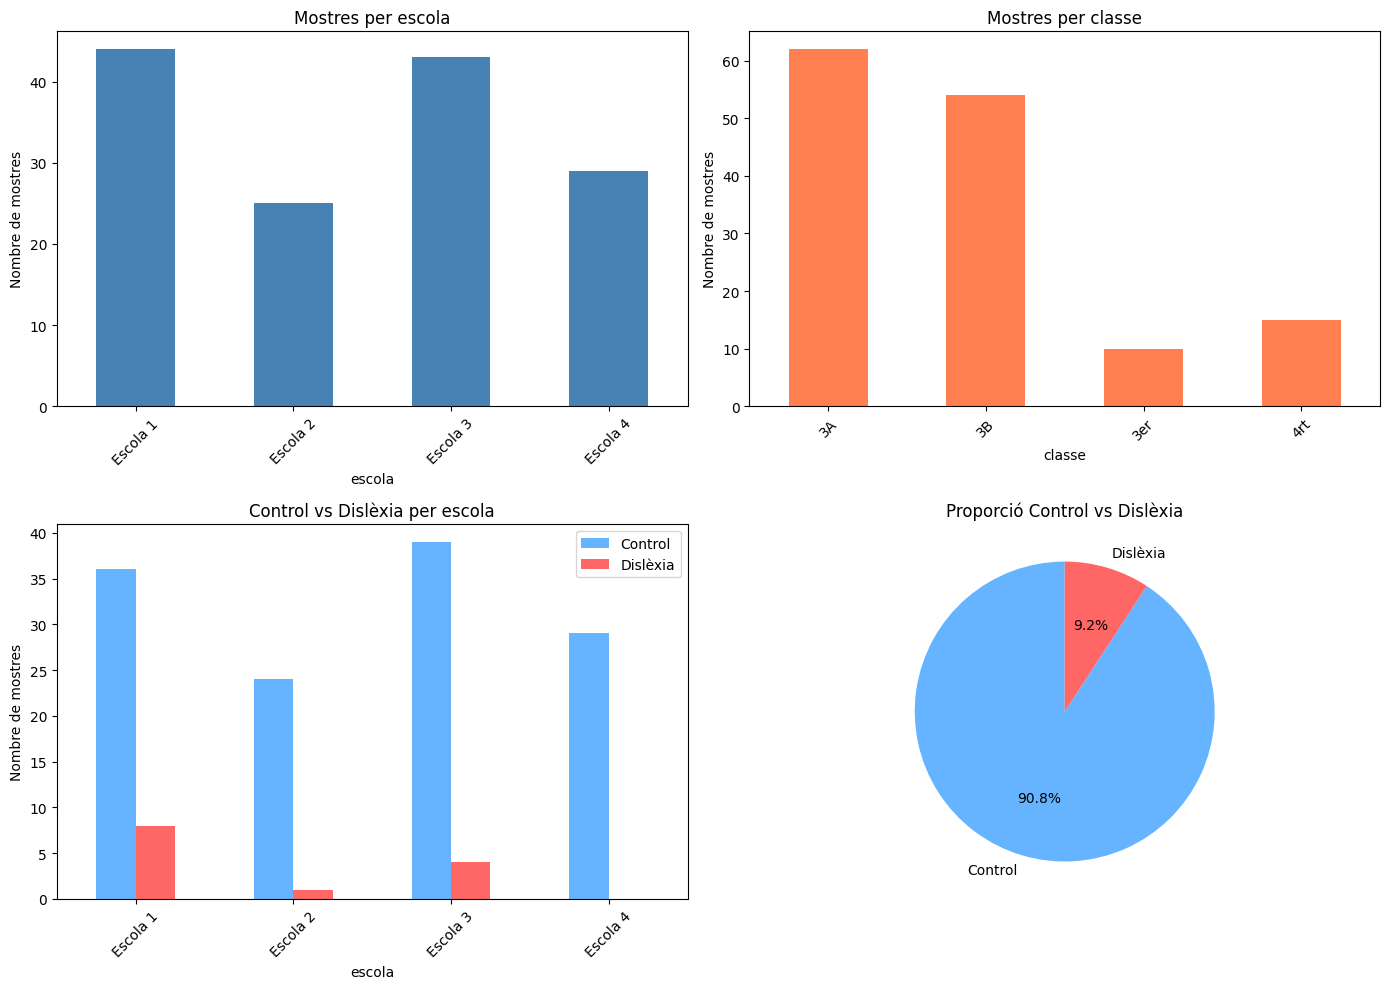

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mostres per escola
ax = axes[0, 0]
df.groupby("escola").size().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Mostres per escola")
ax.set_ylabel("Nombre de mostres")
ax.tick_params(axis="x", rotation=45)

# 2. Mostres per classe
ax = axes[0, 1]
df.groupby("classe").size().plot(kind="bar", ax=ax, color="coral")
ax.set_title("Mostres per classe")
ax.set_ylabel("Nombre de mostres")
ax.tick_params(axis="x", rotation=45)

# 3. Control vs Dislèxia per escola
ax = axes[1, 0]
ct = df.groupby(["escola", "dislexia"]).size().unstack(fill_value=0)
ct.columns = ["Control", "Dislèxia"] if False in ct.columns else ct.columns
ct.plot(kind="bar", ax=ax, color=["#66b3ff", "#ff6666"])
ax.set_title("Control vs Dislèxia per escola")
ax.set_ylabel("Nombre de mostres")
ax.tick_params(axis="x", rotation=45)

# 4. Proporció dislèxia
ax = axes[1, 1]
counts = df["dislexia"].value_counts()
labels = ["Control", "Dislèxia"] if False in counts.index else list(counts.index)
ax.pie(counts, labels=labels, autopct="%1.1f%%",
    colors=["#66b3ff", "#ff6666"], startangle=90)
ax.set_title("Proporció Control vs Dislèxia")

plt.tight_layout()
plt.show()

### Distribució de dislèxia per escola

Analitzem la proporció de casos de dislèxia i controls en cada escola per comprovar si hi ha una distribució equilibrada entre centres educatius.

<Figure size 1000x600 with 0 Axes>

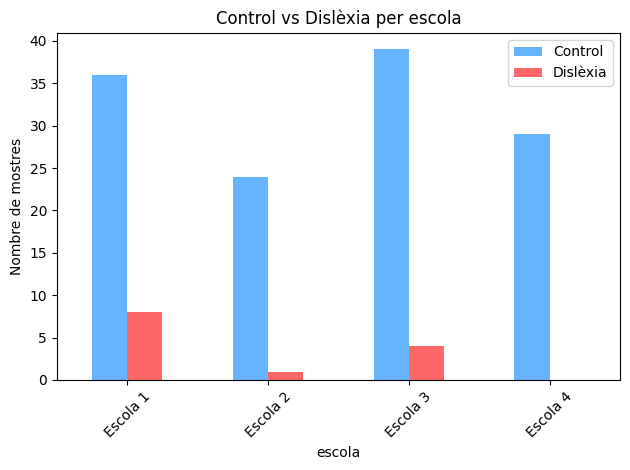

In [5]:
# Control vs Dislèxia per escola
ct = df.groupby(["escola", "dislexia"]).size().unstack(fill_value=0)
ct.columns = ["Control", "Dislèxia"] if False in ct.columns else ct.columns
plt.figure(figsize=(10, 6))
ct.plot(kind="bar", color=["#66b3ff", "#ff6666"])
plt.title("Control vs Dislèxia per escola")
plt.ylabel("Nombre de mostres")
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig("./imatges/dislexia_per_escola.pdf")
plt.show()

## 4. Neteja de dades

Normalitzem i unificam els valors de les columnes categòriques:
- **`llengua_materna`**: Unificar variants (majúscules/minúscules, accents, sinònims)
- **`edat`**: Verificar rangs coherents (esperem 7-9 anys per 3r de primària)

In [6]:
# -- 4a. Normalitzar llengua_materna --
# Primer, posem tot en minúscules i sense espais extres
df["llengua_materna"] = df["llengua_materna"].str.strip().str.lower()

# Mapa d'unificació de variants
LLENGUA_MAP = {
    "castellano": "castellà",
    "castellà": "castellà",
    "català": "català",
    "catala": "català",
    "arab": "àrab",
    "àrab": "àrab",
    "marroquí": "àrab",
    "rus catala": "rus/català",
    "portugues": "portuguès",
    "portuguese": "portuguès",
    "pakistan": "urdú",
    "urdú": "urdú",
    "urdú (nouvingut)": "urdú",
    "nepal": "nepalès",
    "español latino": "castellà",
    "sirià": "àrab",
    "russian": "rus",
}

df["llengua_materna"] = df["llengua_materna"].map(LLENGUA_MAP).fillna(df["llengua_materna"])

print("Llengües maternes després de normalitzar:")
print(df["llengua_materna"].value_counts().to_string())

Llengües maternes després de normalitzar:
llengua_materna
castellà      64
català        54
àrab          19
urdú           2
rus/català     1
nepalès        1


### Visualització de la llengua materna

Comprovem la distribució de la llengua materna dels participants per valorar la diversitat lingüística de la mostra i identificar possibles variables de confusió en l'anàlisi.

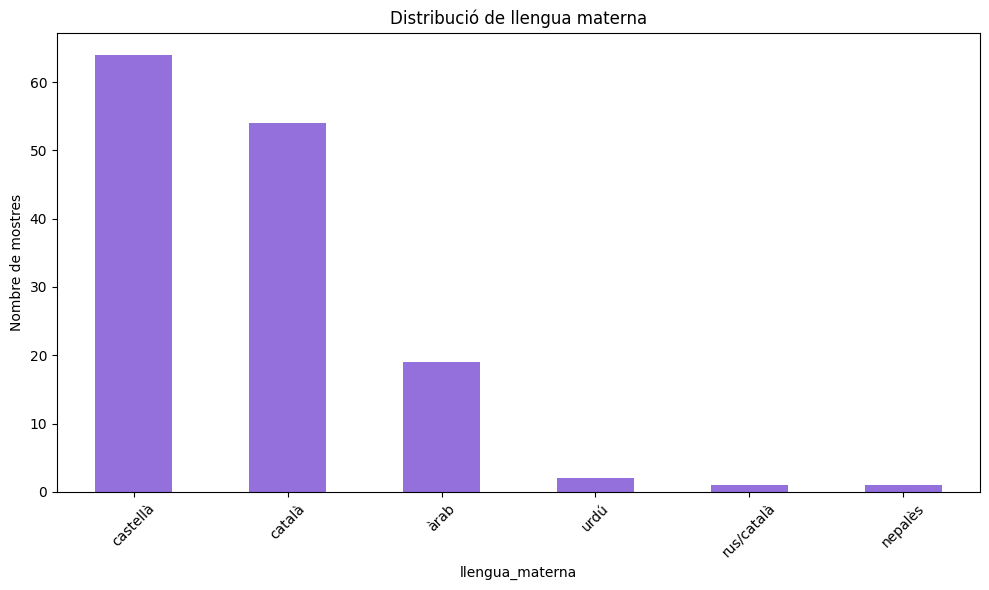

In [7]:
# Visualitzar distribucio de llengua materna
plt.figure(figsize=(10, 6))
df["llengua_materna"].value_counts().plot(kind="bar", color="mediumpurple")
plt.title("Distribució de llengua materna")
plt.ylabel("Nombre de mostres")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Càrrega d'àudios i extracció de característiques bàsiques

Carreguem cada fitxer `.wav` per obtenir:
- **Durada** (segons)
- **Sample rate**
- **Senyal d'àudio** (array numpy)

In [ ]:
import subprocess

TARGET_SR = 22050  # Sample rate estàndard per a anàlisi d'àudio
FFMPEG_BIN = imageio_ffmpeg.get_ffmpeg_exe()

def load_audio_ffmpeg(filepath, sr=TARGET_SR):
    """Carrega un fitxer d'àudio usant directament el binari ffmpeg d'imageio-ffmpeg."""
    cmd = [
        FFMPEG_BIN, "-i", str(filepath),
        "-f", "s16le",
        "-acodec", "pcm_s16le",
        "-ar", str(sr),
        "-ac", "1",    
        "-loglevel", "error",
        "pipe:1"       
    ]
    result = subprocess.run(cmd, capture_output=True)
    if result.returncode != 0:
        raise RuntimeError(f"ffmpeg error: {result.stderr.decode()}")
    y = np.frombuffer(result.stdout, dtype=np.int16).astype(np.float32) / 32768.0
    return y, sr

durades = []

print(f"Carregant {len(df)} fitxers d'àudio amb ffmpeg directe...")
for i, row in df.iterrows():
    try:
        y, sr = load_audio_ffmpeg(row["fitxer"], sr=TARGET_SR)
        durades.append(len(y) / sr)
    except Exception as e:
        print(f"  ✗ Error carregant {row['fitxer']}: {e}")
        durades.append(None)

df["durada_seg"] = durades

carregats = df["durada_seg"].notna().sum()
print(f"✓ {carregats}/{len(df)} àudios carregats correctament")
print(f"Durada mitjana: {df['durada_seg'].mean():.1f}s (min: {df['durada_seg'].min():.1f}s, max: {df['durada_seg'].max():.1f}s)")

Carregant 141 fitxers d'àudio amb ffmpeg directe...
✓ 141/141 àudios carregats correctament
Durada mitjana: 67.3s (min: 25.1s, max: 197.5s)


## 6. Visualització exploratòria

Representem la distribució de les durades de lectura per grup (dislèxia vs. control) per detectar valors atípics i observar possibles diferències abans del modelatge.

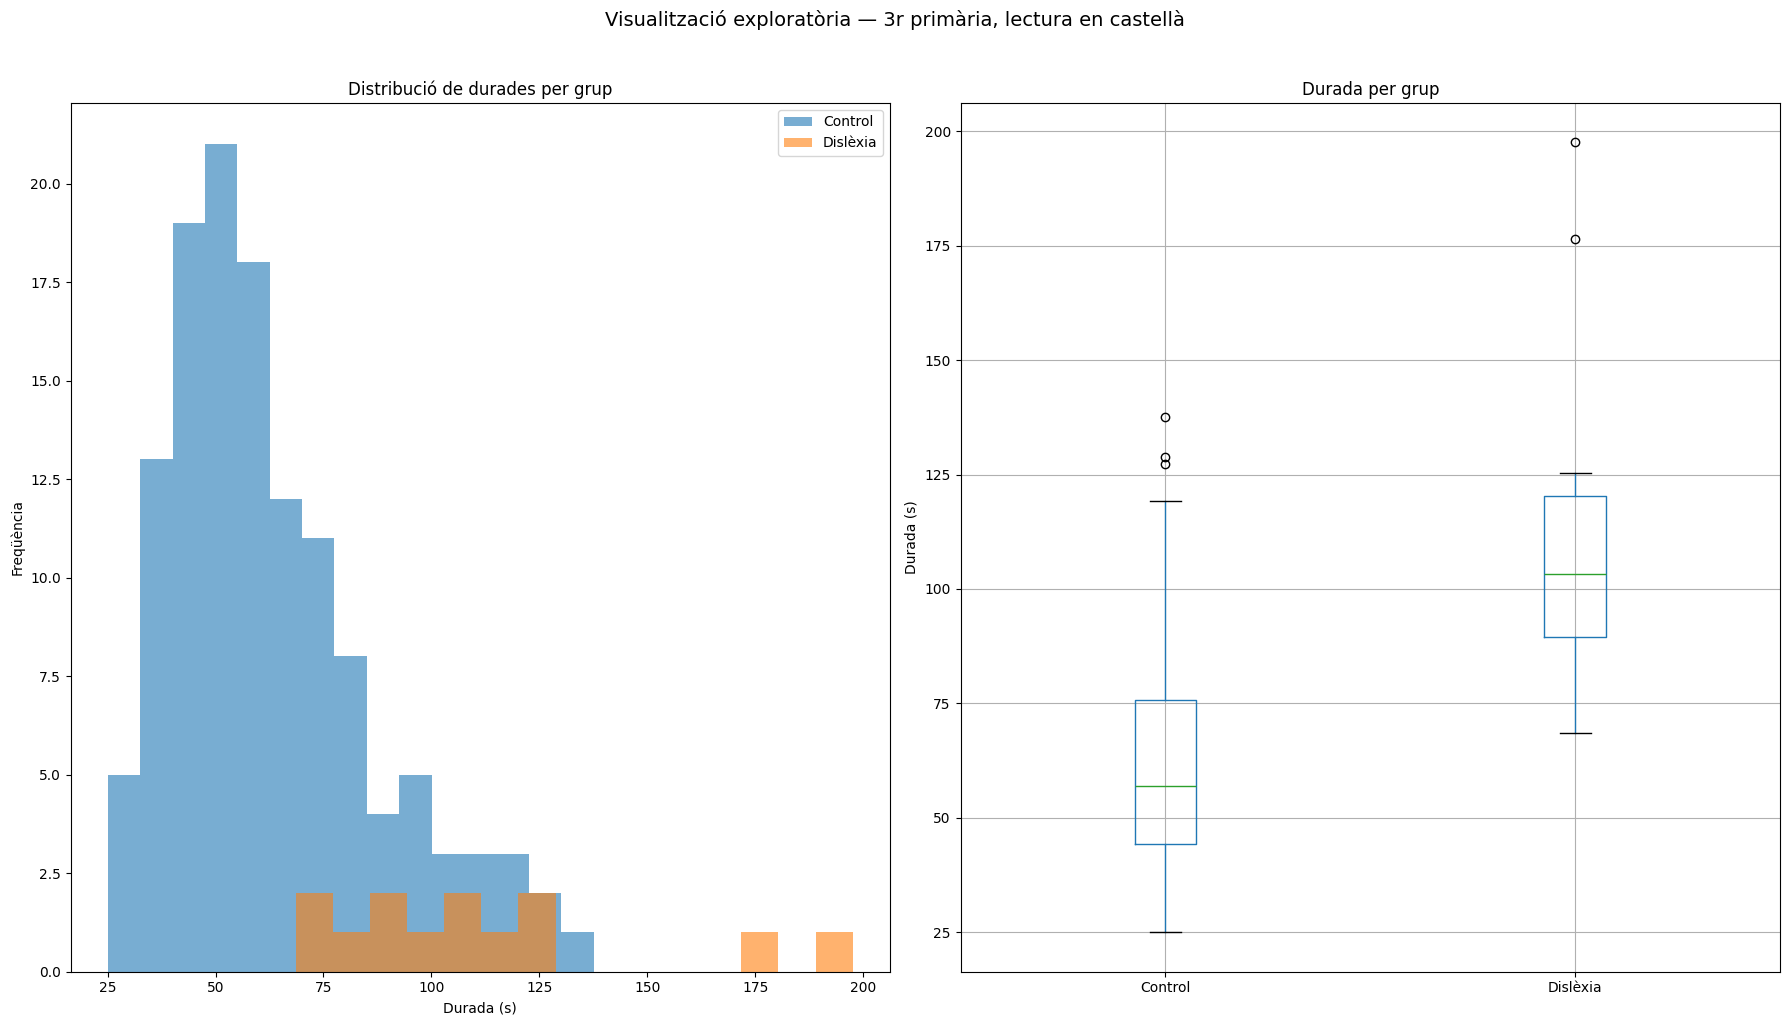

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# 1. Distribució de durades per grup (Dislèxia vs Control)
ax = axes[0]
for label, group in df.groupby("dislexia"):
    tag = "Dislèxia" if label else "Control"
    ax.hist(group["durada_seg"].dropna(), bins=15, alpha=0.6, label=tag)
ax.set_xlabel("Durada (s)")
ax.set_ylabel("Freqüència")
ax.set_title("Distribució de durades per grup")
ax.legend()

# 2. Boxplot de durades per grup
ax = axes[1]
df.boxplot(column="durada_seg", by="dislexia", ax=ax)
ax.set_xticklabels(["Control", "Dislèxia"])
ax.set_title("Durada per grup")
ax.set_xlabel("")
ax.set_ylabel("Durada (s)")
fig.suptitle("")

plt.suptitle("Visualització exploratòria — 3r primària, lectura en castellà", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Guardar el DataFrame net

Guardem les metadades i característiques en un CSV (sense el senyal d'àudio cru) per poder-les reutilitzar sense haver de recarregar tots els àudios.

In [10]:
cols_to_save = [c for c in df.columns if c not in ["senyal", "nom_fitxer"]]
df[cols_to_save].to_csv("./datasets/metadata.csv", index=False, encoding="utf-8-sig")
print(f"✓ Guardat './datasets/metadata.csv' amb {len(df)} registres i {len(cols_to_save)} columnes")
print(f"  Columnes: {cols_to_save}")

✓ Guardat './datasets/metadata.csv' amb 141 registres i 9 columnes
  Columnes: ['fitxer', 'nom', 'edat', 'escola', 'classe', 'dislexia', 'text_llegit', 'llengua_materna', 'durada_seg']
